<a href="https://colab.research.google.com/github/LorenzoBioinfo/import-biology/blob/main/notebooks/DEG_Analysis_pyDESeq2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Differential Gene Expression Analysis con pyDESeq2

In questo notebook, vedremo come eseguire una Differential gene expression (DEG) analysis.

Utilizzeremo il dataset : RNA-sequencing of pretreatment AB1 (mesothelioma) and Renca (kidney cancer) tumours mice both respondant and non-respondant to immunotherapy with CTLA4 and PD-L1 (GSE117358).
Il dataset contiene i dati da 48 topi con 2 tipi diversi di tumore:

* AB1 - mesotelioma (tumore della pleura)
* Renca — carcinoma renale

Per ogni modello tumorale hanno trattato i topi con immunoterapia (anticorpi anti-CTLA4 + anti-PD-L1) e poi li hanno divisi in base alla risposta:

* *Responders*, se il tumore ha risposto al trattamento
* *Non-responders*, se il tumore non ha risposto

L'RNAseq è fatto pre-trattamento :  l'idea è capire se esiste già una firma molecolare nel tumore che predice chi risponderà e chi no, prima ancora di iniziare la terapia.
In numeri:

- 24 campioni AB1 → 12 responders + 12 non-responders
- 24 campioni Renca → 12 responders + 12 non-responders

48 campioni totali

In [314]:
### Richiamiamo le librerie principali e installiamo pydeseq2 e GEOparse
import os
import pickle as pkl
import numpy as np

!pip install pydeseq2
!pip install GEOparse

In [315]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

In [316]:
# Scarichiamo ora i dati
import GEOparse
gse = GEOparse.get_GEO("GSE117358", destdir="./data")

29-May-2026 15:27:53 DEBUG utils - Directory ./data already exists. Skipping.
DEBUG:GEOparse:Directory ./data already exists. Skipping.
29-May-2026 15:27:53 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
29-May-2026 15:27:53 INFO GEOparse - Parsing ./data/GSE117358_family.soft.gz: 
INFO:GEOparse:Parsing ./data/GSE117358_family.soft.gz: 
29-May-2026 15:27:53 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
29-May-2026 15:27:53 DEBUG GEOparse - SERIES: GSE117358
DEBUG:GEOparse:SERIES: GSE117358
29-May-2026 15:27:53 DEBUG GEOparse - PLATFORM: GPL13112
DEBUG:GEOparse:PLATFORM: GPL13112
29-May-2026 15:27:53 DEBUG GEOparse - SAMPLE: GSM3291713
DEBUG:GEOparse:SAMPLE: GSM3291713
29-May-2026 15:27:53 DEBUG GEOparse - SAMPLE: GSM3291714
DEBUG:GEOparse:SAMPLE: GSM3291714
29-May-2026 15:27:53 DEBUG GEOparse - SAMPLE: GSM3291715
DEBUG:GEOparse:SAMPLE: GSM3291715
29-May-2026 15:27:53 DEBUG GEOparse - SAMPLE: GSM329

In [317]:
# Verichifichiamo il contenuto della cartella
! ls data


GSE117358_family.soft.gz


Leggiamo dall'oggetto GSE il contenuto dei dati.

In [318]:

print("GSM: GSE117358")
for gsm_name, gsm in gse.gsms.items():
    print("Name: ", gsm_name)
    print("Metadata:",)
    for key, value in gsm.metadata.items():
        print(" - %s : %s" % (key, ", ".join(value)))
    print ("Table data:",)
    print (gsm.table.head())
    break

GSM: GSE117358
Name:  GSM3291713
Metadata:
 - title : AB1 Responder rep1 [AB01]
 - geo_accession : GSM3291713
 - status : Public on Jul 18 2019
 - submission_date : Jul 19 2018
 - last_update_date : Nov 17 2020
 - type : SRA
 - channel_count : 1
 - source_name_ch1 : AB1_Responder
 - organism_ch1 : Mus musculus
 - taxid_ch1 : 10090
 - characteristics_ch1 : host strain: balb/c, host mouse age: 8-9 weeks, host mouse gender: female, tumor cells: AB1, tumor type: mesothelioma, treatment: anti-CTLA4 plus anti-PDL-1, timepoint: day 0 - pretreatment, response to immunotherapy: Responder, rna 260/280: 2.04, rna 260/230: 2.03
 - growth_protocol_ch1 : AB1 or Renca tumour cells were subcutaneously injected into Balb/c mice, and whole tumour surgically removed 8 or 10 days after (respectively)"
 - molecule_ch1 : total RNA
 - extract_protocol_ch1 : Frozen tumours were dissociated in Trizol using a TissueRuptor, total RNA was extracted using chloroform and purified on Rneasy MiniElute columns., RNA l

Leggiamo dove sono salvati i file con le conte.

In [319]:
print(gse.metadata['supplementary_file'])

['ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE117nnn/GSE117358/suppl/GSE117358_genecounts.csv.gz']


In [320]:
import pandas as pd
url = gse.metadata['supplementary_file'][0]


In [321]:
counts = pd.read_csv(url, compression="gzip")
print(counts.shape)
print(counts.head())

(39637, 51)
   AB01   AB02  AB09   AB10  AB17  AB18  AB25   AB26  AB33   AB34  ...  RZ66  \
0  5344   6003  5392   5452  4652  4620  4510   5077  4313   6617  ...  3032   
1     0      0     0      0     0     0     0      0     0      0  ...     0   
2   812    967   841    882   658   434   686    867   568   1247  ...   766   
3  8346  14646  6320  16274  5830  5422  4158  13197  4356  13387  ...  1288   
4    88    142    83    128    70    75    51    107    45    143  ...    13   

   RZ67  RZ68  RZ69  RZ70  RZ71  RZ72           EnsemblID  Symbol  \
0  3635  3756  3248  3257  3548  3442  ENSMUSG00000000001   Gnai3   
1     0     0     0     0     0     0  ENSMUSG00000000003    Pbsn   
2   732   830   830   726   716   767  ENSMUSG00000000028   Cdc45   
3  2907  1896   515  1807  2643  1693  ENSMUSG00000000031     H19   
4    30    27    20    22    19    16  ENSMUSG00000000037   Scml2   

                                         Description  
0  guanine nucleotide binding protein

In [322]:
print(counts.columns)


# Verifichiamo che ci siano tutti i campioni nella matrice
print(len(counts.columns[:-3]))
counts.columns[:-3]

Index(['AB01', 'AB02', 'AB09', 'AB10', 'AB17', 'AB18', 'AB25', 'AB26', 'AB33',
       'AB34', 'AB41', 'AB42', 'AB49', 'AB50', 'AB57', 'AB58', 'AB65', 'AB66',
       'AB67', 'AB68', 'AB69', 'AB70', 'AB71', 'AB72', 'RZ01', 'RZ02', 'RZ09',
       'RZ10', 'RZ17', 'RZ18', 'RZ25', 'RZ26', 'RZ33', 'RZ34', 'RZ41', 'RZ42',
       'RZ49', 'RZ50', 'RZ57', 'RZ58', 'RZ65', 'RZ66', 'RZ67', 'RZ68', 'RZ69',
       'RZ70', 'RZ71', 'RZ72', 'EnsemblID', 'Symbol', 'Description'],
      dtype='object')
48


Index(['AB01', 'AB02', 'AB09', 'AB10', 'AB17', 'AB18', 'AB25', 'AB26', 'AB33',
       'AB34', 'AB41', 'AB42', 'AB49', 'AB50', 'AB57', 'AB58', 'AB65', 'AB66',
       'AB67', 'AB68', 'AB69', 'AB70', 'AB71', 'AB72', 'RZ01', 'RZ02', 'RZ09',
       'RZ10', 'RZ17', 'RZ18', 'RZ25', 'RZ26', 'RZ33', 'RZ34', 'RZ41', 'RZ42',
       'RZ49', 'RZ50', 'RZ57', 'RZ58', 'RZ65', 'RZ66', 'RZ67', 'RZ68', 'RZ69',
       'RZ70', 'RZ71', 'RZ72'],
      dtype='object')

In [323]:
samples=counts.columns[:-3].to_list()
AB1 = [sample for sample in samples if "AB" in sample]
RZ = [sample for sample in samples if "RZ" in sample]

print(f"Gli AB1 sono {len(AB1)}")
print(f"Gli RZ sono {len(RZ)}")


Gli AB1 sono 24
Gli RZ sono 24


 Modifichiamo la tabella delle count in modo da avere solo i samples e i nomi dei geni
 come indice della matrice. Inoltre pyDeseq2 vuole una matrice samples x geni, con i
 samples sulle righe e i geni come colonne (a differenza di Deseq2 in R). Quest'ultimo passaggio lo faremo subito prima di creare l'oggetto **DeseqDataSet**, prima faremo un po' di pulizia della matrice per rimuovere alcuni geni.



In [324]:
clean_counts=counts.iloc[:,0:-3]
clean_counts=clean_counts.set_index(counts["Symbol"])


 Dobbiamo ora creare, visto che non è fornita direttamente, la tabella con i metadati per ogni campione.
 Vediamo cosa abbiamo per ogni campione all'interno dell'oggetto GSE

In [325]:
import pandas as pd

rows = []
for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata['title'][0]
    characteristics = gsm.metadata['characteristics_ch1']
    rows.append({
        "sample": gsm_name,
        "title": title,
        "characteristics": str(characteristics)
    })

meta_df_temp = pd.DataFrame(rows)
print(meta_df_temp.head(10).to_string(index=False))

    sample                         title                                                                                                                                                                                                                                                                                     characteristics
GSM3291713     AB1 Responder rep1 [AB01]     ['host strain: balb/c', 'host mouse age: 8-9 weeks', 'host mouse gender: female', 'tumor cells: AB1', 'tumor type: mesothelioma', 'treatment: anti-CTLA4 plus anti-PDL-1', 'timepoint: day 0 - pretreatment', 'response to immunotherapy: Responder', 'rna 260/280: 2.04', 'rna 260/230: 2.03']
GSM3291714 AB1 Non-responder rep1 [AB02] ['host strain: balb/c', 'host mouse age: 8-9 weeks', 'host mouse gender: female', 'tumor cells: AB1', 'tumor type: mesothelioma', 'treatment: anti-CTLA4 plus anti-PDL-1', 'timepoint: day 0 - pretreatment', 'response to immunotherapy: Non-responder', 'rna 260/280: 2.05', 'rna 260/230: 2.21']
G

Cerchiamo di sintetizzare le informazioni contenute per ottenere un dataframe con 3 colonne:
 * SampleID
 * Tumor_Type
 * Treatment_Response

In [326]:
meta_df_temp["SampleID"]=meta_df_temp["title"].apply(lambda x: x.split("[")[1].split("]")[0])




In [327]:
import ast
meta_df_temp["Tumor_Type"]=meta_df_temp["characteristics"].apply(lambda x: ast.literal_eval(x)[3].replace("tumor cells: ",""))
meta_df_temp["Treatment_Response"]=meta_df_temp["characteristics"].apply(lambda x: ast.literal_eval(x)[7].replace("response to immunotherapy: ",""))



In [328]:
metadata=meta_df_temp[["SampleID","Tumor_Type","Treatment_Response"]]

metadata.head()

,SampleID,Tumor_Type,Treatment_Response
0,AB01,AB1,Responder
1,AB02,AB1,Non-responder
2,AB09,AB1,Responder
3,AB10,AB1,Non-responder
4,AB17,AB1,Responder


In [329]:
pd.crosstab(metadata["Tumor_Type"],metadata["Treatment_Response"])

Treatment_Response,Non-responder,Responder
Tumor_Type,,
AB1,12,12
Renca,12,12


Abbiamo ora i due componenti fondamentali per iniziare l'analisi:
la matrice con le count e i metadata.

### Prepreocessing della matrice di counts

Prima di procedere analizziamo la matrice di counts.

In [330]:
## Controlliamo se ci sono NAN

# Controlliamo che nessun gene abbia un valore mancante
any(clean_counts.isna().sum(axis=1)>0)

False

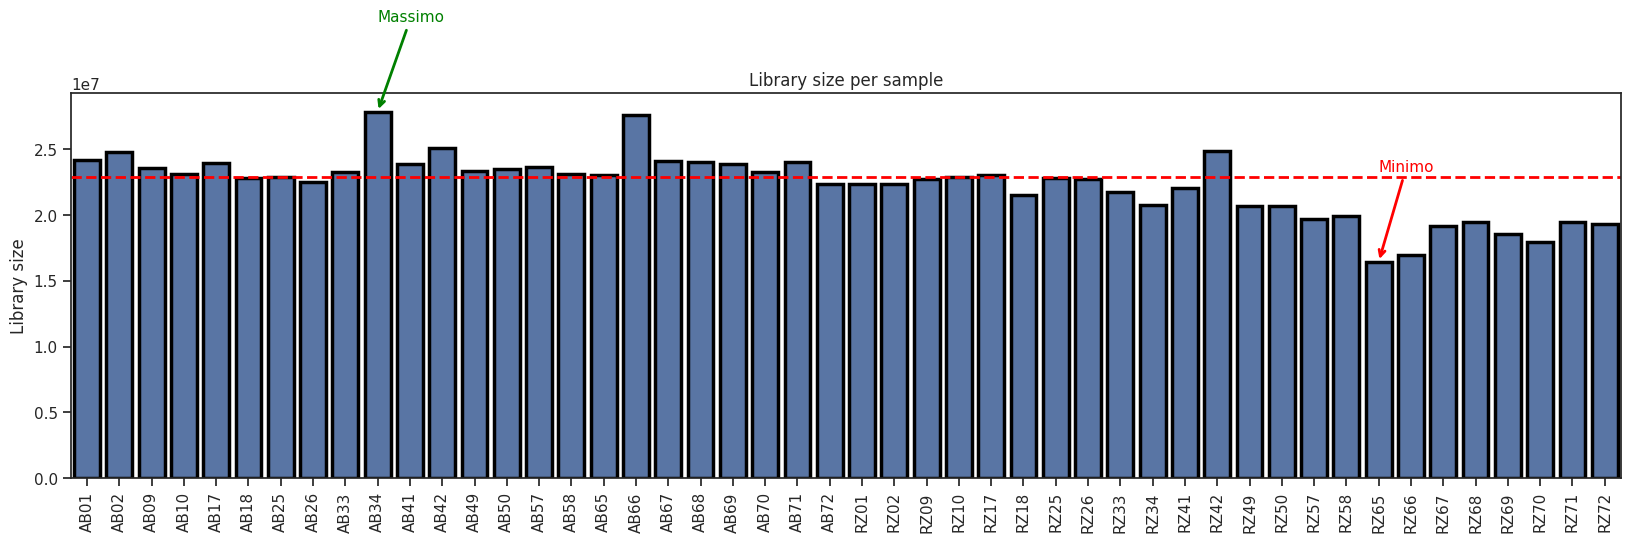

In [331]:
### Distribuzione delle library size
# Sommiamo le counts di ogni campione e confrontiamole per vedere se ci sono
# campioni con library size molto diverse tra loro

import matplotlib.pyplot as plt
import seaborn as sns
toplot=clean_counts.sum(axis=0)

median_librarysize=toplot.median()


min_sample = toplot.idxmin()
min_val = toplot.min()

max_sample = toplot.idxmax()
max_val = toplot.max()

samples = toplot.index.tolist()
x_pos_min = samples.index(min_sample)
x_pos_max = samples.index(max_sample)


plt.figure(figsize=(20,5))
sns.barplot(toplot, edgecolor="black",linewidth=2.5)
plt.axhline(
    median_librarysize,
    color="red",
    linewidth=2,
    linestyle="--",
    label=f"Mediana: {median_librarysize:.1f}"
)

plt.annotate(
    "Minimo",
    xy=(x_pos_min, min_val),
    xytext=(x_pos_min, min_val + median_librarysize * 0.3),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    color="red",
    fontsize=11
)

plt.annotate(
    "Massimo",
    xy=(x_pos_max, max_val),
    xytext=(x_pos_max, max_val + median_librarysize * 0.3),
    arrowprops=dict(
        arrowstyle="->",
        color="green",
        lw=2
    ),
    color="green",
    fontsize=11
)
plt.ylabel("Library size")
plt.title("Library size per sample")
plt.xticks(rotation=90)
plt.show()



Visualizziamo con un boxplot la distribuzione

Text(0.5, 1.0, 'Library size per sample')

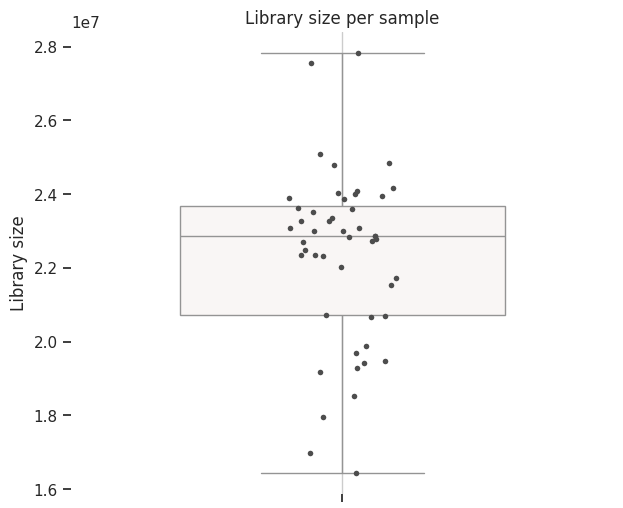

In [332]:

f, ax = plt.subplots(figsize=(7, 6))

sns.set_theme(style="ticks")



sns.boxplot(
    toplot,   width=.6, palette="vlag"
)


sns.stripplot(toplot, size=4, color=".3")


ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)

plt.ylabel("Library size")
plt.title("Library size per sample")

Non dovrebbero esserci outliers dall'immagine del boxplot. Verifichiamolo flaggando come outlier i campioni fuori da Q1 - 1.5 x IQR e  Q3 + 1.5 x IQR.

In [333]:
from numpy._core.defchararray import lower
Q1=toplot.quantile(0.25)
Q3=toplot.quantile(0.75)
IQR=Q3-Q1

upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR

outliers=toplot[(toplot>upper_bound) | (toplot<lower_bound)]
outliers

,0


Questo ci conferma che non ci sono outliers, almeno guardando la distribuzione completa. Proviamo però ora a guardare separatamente i campioni AB e Renca

In [334]:
# Ora trasformiamo in un dataframe
toplot = toplot.reset_index()
toplot.columns = ["Sample", "library_size"]
toplot["Tumor_Type"] = toplot["Sample"].str[:2]
toplot.head()

,Sample,library_size,Tumor_Type
0,AB01,24168419,AB
1,AB02,24800196,AB
2,AB09,23587492,AB
3,AB10,23084034,AB
4,AB17,23957641,AB


Text(0.5, 1.0, 'Library size per sample')

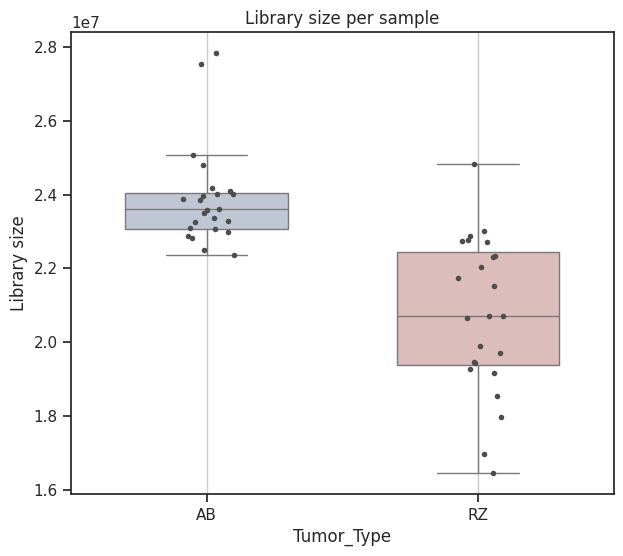

In [335]:
f, ax = plt.subplots(figsize=(7, 6))

sns.boxplot(
    toplot, x="Tumor_Type",y="library_size",  width=.6, palette="vlag",showfliers=False
)


sns.stripplot(toplot,x="Tumor_Type",y="library_size", size=4, color=".3",)


ax.xaxis.grid(True)


plt.ylabel("Library size")
plt.title("Library size per sample")

Vediamo 2 campioni AB che sono molto al di sopra della distribuzione. Cerchiamo di capire chi sono.

In [336]:
# Ordiniamo per la library size
possible_outliers_ab=toplot[toplot.Tumor_Type=="AB"].sort_values("library_size",ascending=False).head(2)

metadata[metadata.SampleID.isin(possible_outliers_ab.Sample.tolist())]

,SampleID,Tumor_Type,Treatment_Response
9,AB34,AB1,Non-responder
17,AB66,AB1,Non-responder


I campioni con la library size così alta sono 2 Non-responders del mesotelioma.
Potremmo decidere di rimuoverli ma il design verrebbe sbilanciato con 12 responders e 10 responders. Valutiamo prima di escluderli il numero di geni con counts>0 in ogni sample, e controlliamo se questi due campioni hanno un numero più elevato o meno.

In [337]:
genetoplot=(clean_counts>0).sum()
genetoplot = genetoplot.reset_index()
genetoplot.columns = ["Sample", "Expressed_genes"]
genetoplot.head()

,Sample,Expressed_genes
0,AB01,21815
1,AB02,22251
2,AB09,22447
3,AB10,22160
4,AB17,22516


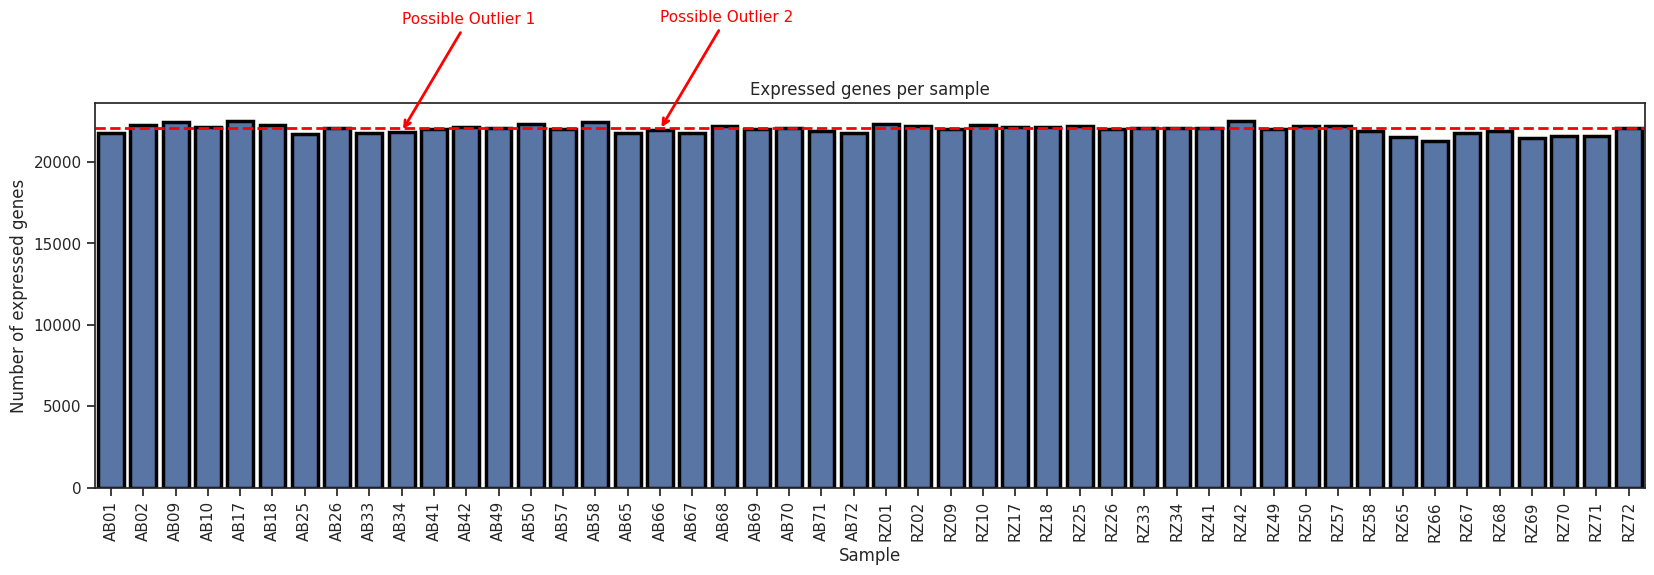

In [338]:
median_gene=genetoplot.Expressed_genes.median()


samples = genetoplot.Sample.tolist()
x_pos_possible_outliers1 = samples.index("AB34")
x_pos_possible_outliers2 = samples.index("AB66")

val_outliers1 = genetoplot[genetoplot.Sample=="AB34"].Expressed_genes
val_outliers2 = genetoplot[genetoplot.Sample=="AB66"].Expressed_genes




plt.figure(figsize=(20,5))
sns.barplot(genetoplot,x="Sample",y="Expressed_genes", edgecolor="black",linewidth=2.5)
plt.axhline(
    median_gene,
    color="red",
    linewidth=2,
    linestyle="--",
    label=f"Mediana: {median_librarysize:.1f}"
)

plt.annotate(
    "Possible Outlier 1",
    xy=(x_pos_possible_outliers1, val_outliers1),
    xytext=(x_pos_possible_outliers1, val_outliers1 + median_gene * 0.3),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    color="red",
    fontsize=11
)

plt.annotate(
    "Possible Outlier 2",
    xy=(x_pos_possible_outliers2, val_outliers2),
    xytext=(x_pos_possible_outliers2,val_outliers2 + median_gene * 0.3),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=2
    ),
    color="red",
    fontsize=11
)
plt.ylabel("Number of expressed genes")
plt.title("Expressed genes per sample")
plt.xticks(rotation=90)
plt.show()

Ok sembrano in linea con gli altri campioni. Per il momento non escludiamoli dall'analisi.

# Distribuzione delle counts per gene

La maggior parte dei geni in un dataset RNA-seq ha counts molto basse o zero. Questo è normale. Plottiamo un istogramma delle counts media e mediana per gene sia in scala normale che in scala log.

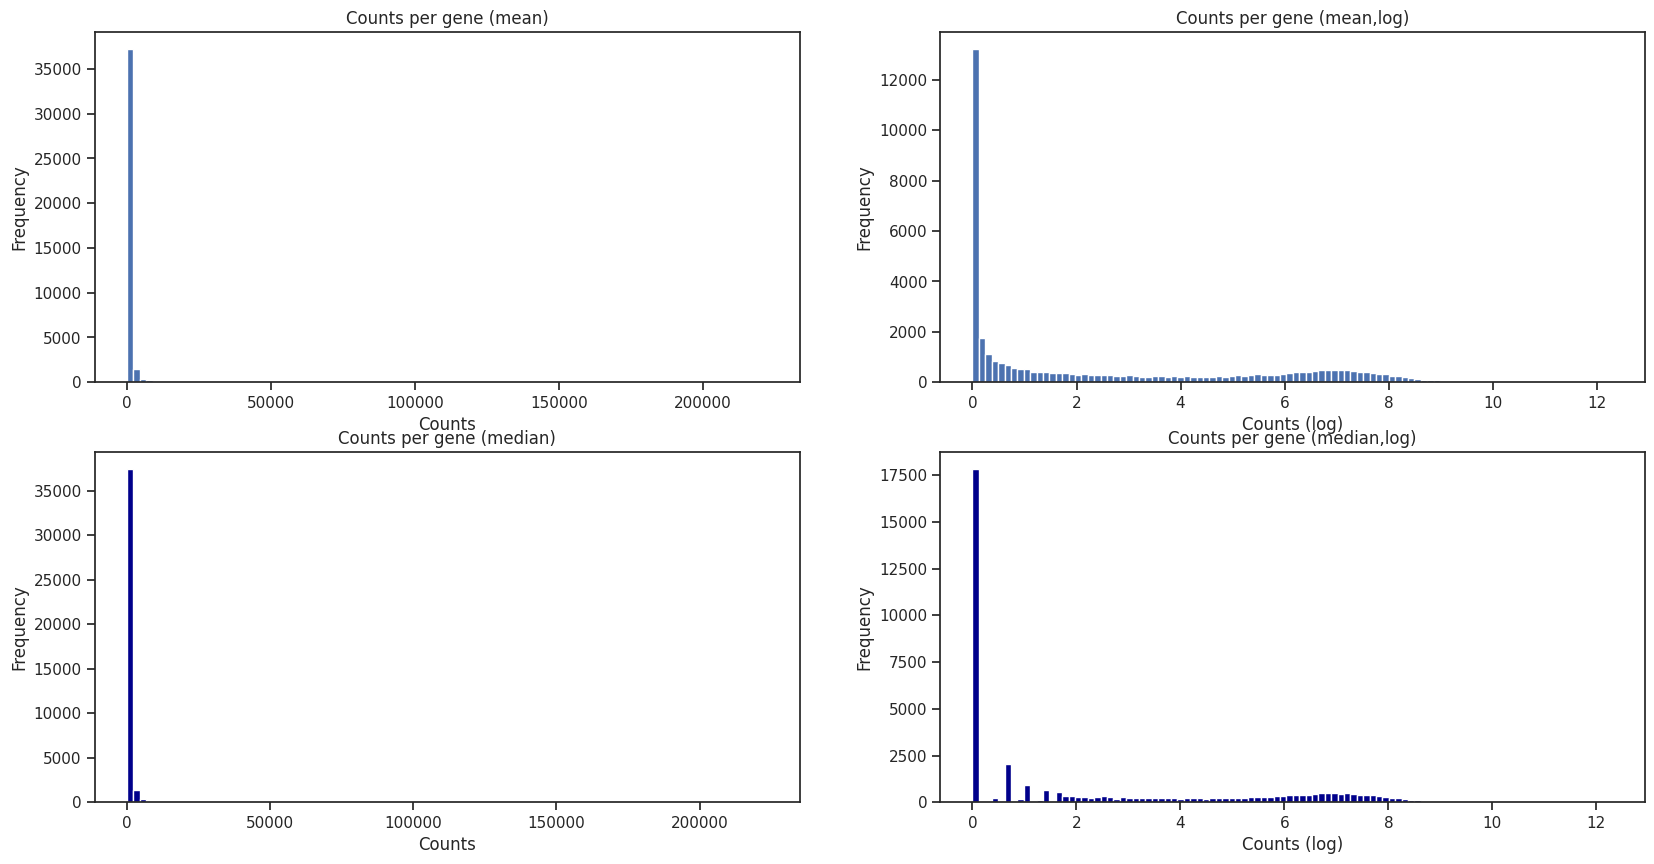

In [339]:
import numpy as np

fig, axs = plt.subplots(2, 2, figsize=(20, 10))

clean_counts.mean(axis=1).plot(kind="hist", bins=100,ax=axs[0,0])
axs[0,0].set_title("Counts per gene (mean)")
axs[0,0].set_xlabel("Counts")
axs[0,0].set_ylabel("Frequency")

np.log1p(clean_counts.mean(axis=1)).plot(kind="hist", bins=100,ax=axs[0,1])
axs[0,1].set_title("Counts per gene (mean,log)")
axs[0,1].set_xlabel("Counts (log)")
axs[0,1].set_ylabel("Frequency")



clean_counts.median(axis=1).plot(kind="hist", bins=100,ax=axs[1,0],color="darkblue")
axs[1,0].set_title("Counts per gene (median)")
axs[1,0].set_xlabel("Counts")
axs[1,0].set_ylabel("Frequency")

np.log1p(clean_counts.median(axis=1)).plot(kind="hist", bins=100,ax=axs[1,1],color="darkblue")
axs[1,1].set_title("Counts per gene (median,log)")
axs[1,1].set_xlabel("Counts (log)")
axs[1,1].set_ylabel("Frequency")


plt.show()

Come atteso la maggior parte dei geni ha un numero di count medio molto basso o zero. Per l'analisi filtriamo i geni, teniamo solo i geni che hanno un numero di count di 10 in almeno 12 campioni.


In [340]:
print(f"Geni iniziali: {len(clean_counts)}")



Geni iniziali: 39637


In [341]:
keep=(clean_counts>=10).sum(axis=1)>=12
filtered_clean_counts=clean_counts[keep]
print(f"Geni finali: {len(filtered_clean_counts)}")

Geni finali: 16574


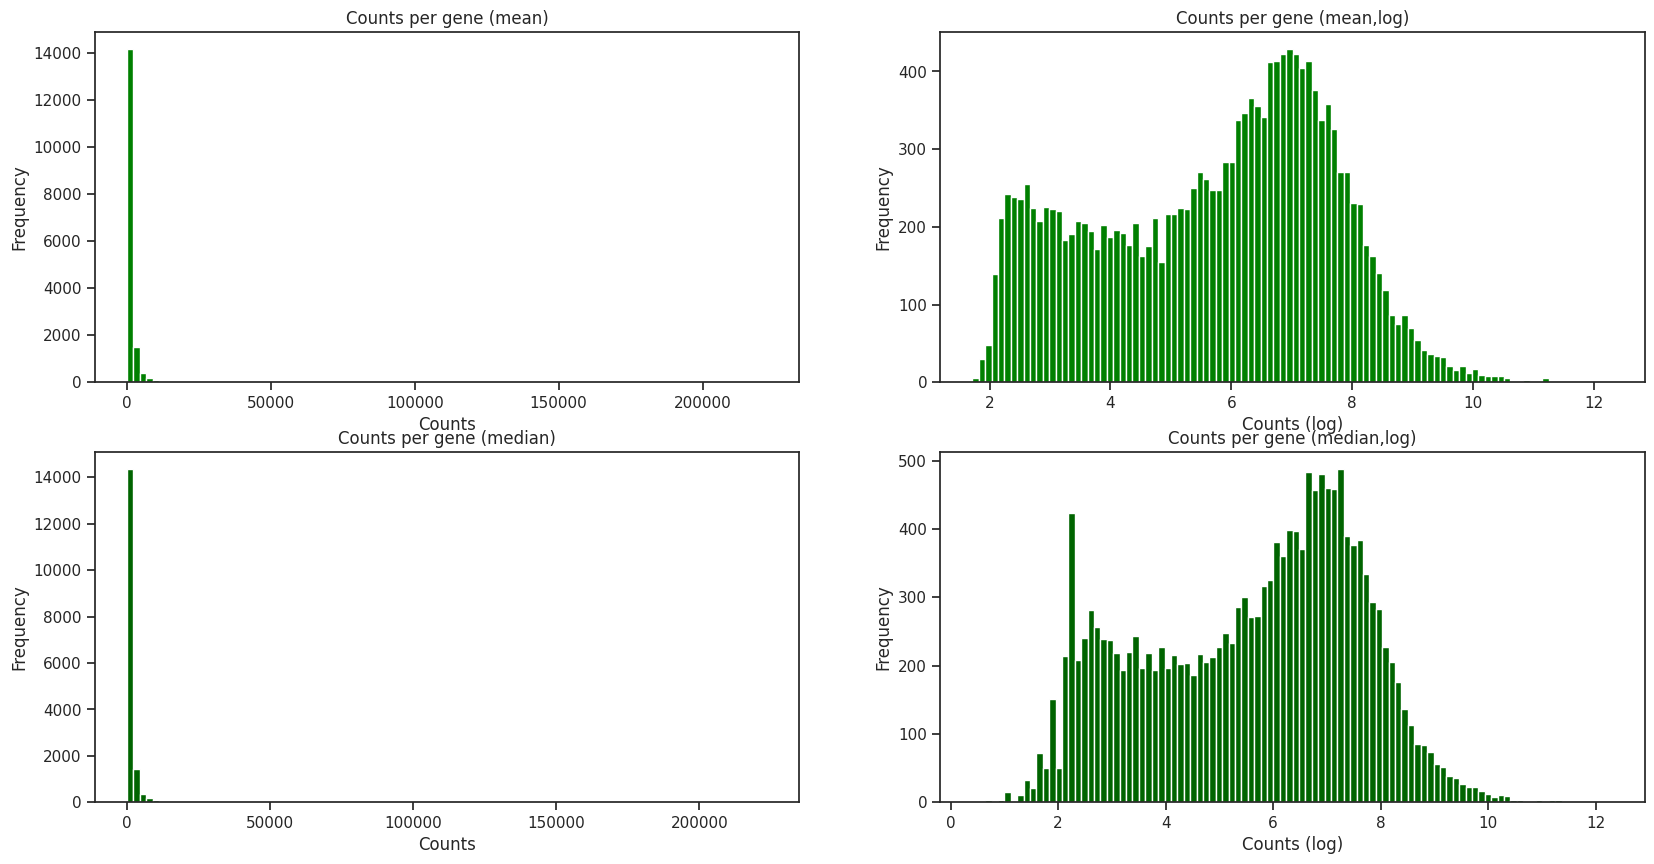

In [342]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

filtered_clean_counts.mean(axis=1).plot(kind="hist", bins=100,ax=axs[0,0],color="green")
axs[0,0].set_title("Counts per gene (mean)")
axs[0,0].set_xlabel("Counts")
axs[0,0].set_ylabel("Frequency")

np.log1p(filtered_clean_counts.mean(axis=1)).plot(kind="hist", bins=100,ax=axs[0,1],color="green")
axs[0,1].set_title("Counts per gene (mean,log)")
axs[0,1].set_xlabel("Counts (log)")
axs[0,1].set_ylabel("Frequency")



filtered_clean_counts.median(axis=1).plot(kind="hist", bins=100,ax=axs[1,0],color="darkgreen")
axs[1,0].set_title("Counts per gene (median)")
axs[1,0].set_xlabel("Counts")
axs[1,0].set_ylabel("Frequency")

np.log1p(filtered_clean_counts.median(axis=1)).plot(kind="hist", bins=100,ax=axs[1,1],color="darkgreen")
axs[1,1].set_title("Counts per gene (median,log)")
axs[1,1].set_xlabel("Counts (log)")
axs[1,1].set_ylabel("Frequency")


plt.show()

# Rimuoviamo geni ribosomiali, mitocondriali e predetti

In [343]:
mask=~filtered_clean_counts.index.str.startswith(("Gm","RP","Mrps","Mrpl"))

final_clean_counts=filtered_clean_counts[mask]
print(f"Geni finali: {len(final_clean_counts)}")

Geni finali: 13455


### Pydeseq2

Siamo pronti a importare la matrice e i metadata nell'oggetto pydeseq2.
E' il momento di trasporre la matrice delle conte in modo da avere i sample sulle righe e i geni come colonne.



In [344]:
pydeseq_counts=final_clean_counts.T
print(pydeseq_counts.head())

# Verifichiamo che siano tutti interi
pydeseq_counts.dtypes

Symbol  Gnai3  Cdc45    H19  Scml2  Narf  Cav2  Scmh1  Cox5a  Tbx2  Ngfr  ...  \
AB01     5344    812   8346     88   961  1670    842   1306    71    18  ...   
AB02     6003    967  14646    142  1025  2385   1272    951   186    75  ...   
AB09     5392    841   6320     83   817  1153    759   1496    72    20  ...   
AB10     5452    882  16274    128   841  2395   1110    935   206    64  ...   
AB17     4652    658   5830     70   986  1073    851    971    66   195  ...   

Symbol  Nudc-ps1  A030001D20Rik  Rnf223  AW046200  1700012D14Rik  KIAA1683  \
AB01         256             31       2        63             56         0   
AB02         314             34       3        93             53         1   
AB09         234             25       5        86             48         1   
AB10         240             50       2        63             56         0   
AB17         232             32       8        73             43         0   

Symbol  Olfr369-ps1  CAAA01180111.2  CH25-39

,0
Symbol,
Gnai3,int64
Cdc45,int64
H19,int64
Scml2,int64
Narf,int64
...,...
KIAA1683,int64
Olfr369-ps1,int64
CAAA01180111.2,int64


In [345]:
metadata.head()

,SampleID,Tumor_Type,Treatment_Response
0,AB01,AB1,Responder
1,AB02,AB1,Non-responder
2,AB09,AB1,Responder
3,AB10,AB1,Non-responder
4,AB17,AB1,Responder


In [346]:
pydeseq_counts.index

Index(['AB01', 'AB02', 'AB09', 'AB10', 'AB17', 'AB18', 'AB25', 'AB26', 'AB33',
       'AB34', 'AB41', 'AB42', 'AB49', 'AB50', 'AB57', 'AB58', 'AB65', 'AB66',
       'AB67', 'AB68', 'AB69', 'AB70', 'AB71', 'AB72', 'RZ01', 'RZ02', 'RZ09',
       'RZ10', 'RZ17', 'RZ18', 'RZ25', 'RZ26', 'RZ33', 'RZ34', 'RZ41', 'RZ42',
       'RZ49', 'RZ50', 'RZ57', 'RZ58', 'RZ65', 'RZ66', 'RZ67', 'RZ68', 'RZ69',
       'RZ70', 'RZ71', 'RZ72'],
      dtype='object')

In [347]:

metadata=metadata.set_index(metadata["SampleID"]).drop("SampleID",axis=1)

In [348]:
metadata

,Tumor_Type,Treatment_Response
SampleID,,
AB01,AB1,Responder
AB02,AB1,Non-responder
AB09,AB1,Responder
AB10,AB1,Non-responder
AB17,AB1,Responder
AB18,AB1,Non-responder
AB25,AB1,Responder
AB26,AB1,Non-responder
AB33,AB1,Responder


In [349]:
dds = DeseqDataSet(
    counts=pydeseq_counts,
    metadata=metadata,
    design="~Treatment_Response")

In [350]:
dds

AnnData object with n_obs × n_vars = 48 × 13455
    obs: 'Tumor_Type', 'Treatment_Response'
    obsm: 'design_matrix'

In [351]:
dds.fit_size_factors()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.07 seconds.



In [352]:
dds.obs["size_factors"]

,size_factors
SampleID,
AB01,1.058749
AB02,1.132114
AB09,1.017436
AB10,1.075050
AB17,1.048726
AB18,0.957169
AB25,0.971903
AB26,1.019509
AB33,1.002826


In [353]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 22.15 seconds.



In [354]:
vst_matrix = dds.layers["vst_counts"]

In [355]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
pcadf=pd.DataFrame(pca.fit_transform(vst_matrix),columns=["PC1","PC2"])

In [356]:
pcadf["Sample"]=pydeseq_counts.index

In [357]:
pcadf=pd.merge(pcadf,metadata,left_on="Sample",right_on="SampleID")

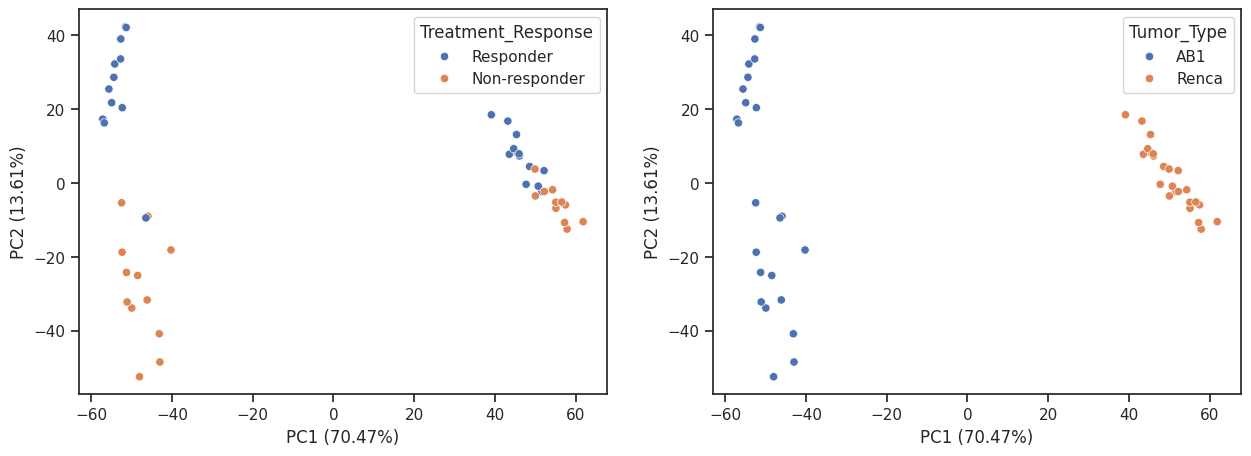

In [358]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

sns.scatterplot(x="PC1",y="PC2",hue="Treatment_Response",data=pcadf,ax=axes[0])
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")


sns.scatterplot(x="PC1",y="PC2",hue="Tumor_Type",data=pcadf,ax=axes[1])
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.show()

Il plot di destra (Tumor_Type) mostra che PC1 separa perfettamente AB1 da Renca.I due tumori sono biologicamente molto diversi, esattamente quello che ci aspettavamo. Questa è la fonte di varianza dominante nel dataset.
Il plot di sinistra (Treatment_Response) mostra qualcosa di interessante:  all'interno di ogni gruppo tumorale c'è una separazione parziale tra responders e non-responders, specialmente in AB1 dove i blu (responders) tendono verso l'alto e gli arancioni verso il basso lungo PC2.


Per le analisi, due cose importanti:

Prima, fare l'analisi DEG separatamente per AB1 e Renca che è la scelta giusta, perché il segnale del tumor type è così dominante che mescolando tutto insieme maschererebbe il segnale della risposta.
Seconda, quando faremo l'analisi combinata (AB1 + Renca insieme) devi assolutamente includere tumor_type nel design di DESeq2 come variabile di confondimento, altrimenti troveremo differenziali solo per tumor type, non per risposta.

## AB1 cell line

In [359]:
metadata_AB1=metadata[metadata.Tumor_Type=="AB1"]
pydeseq_counts_AB1=pydeseq_counts.loc[metadata_AB1.index]

dds_AB1 = DeseqDataSet(
    counts=pydeseq_counts_AB1,
    metadata=metadata_AB1,
    design="~Treatment_Response")


In [360]:
dds_AB1.deseq2()

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 18.74 seconds.

Fitting dispersion trend curve...
... done in 0.49 seconds.

Fitting MAP dispersions...
... done in 29.00 seconds.

Fitting LFCs...
... done in 10.86 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 227 outlier genes.

Fitting dispersions...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 0.21 seconds.



In [361]:
from pydeseq2.ds import DeseqStats

stat_res = DeseqStats(dds_AB1, contrast=["Treatment_Response", "Responder", "Non-responder"])
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Treatment_Response Responder vs Non-responder
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Symbol                                                                          
Gnai3           5003.396732       -0.058911  0.033393 -1.764168  7.770365e-02   
Cdc45            781.635776       -0.314544  0.100472 -3.130652  1.744187e-03   
H19             8595.982579       -1.082872  0.173146 -6.254099  3.998181e-10   
Scml2             82.391267       -0.833870  0.131376 -6.347182  2.192946e-10   
Narf             872.329050        0.186354  0.143001  1.303164  1.925189e-01   
...                     ...             ...       ...       ...           ...   
KIAA1683           0.296147        1.322449  1.672339  0.790778  4.290734e-01   
Olfr369-ps1       14.761436       -0.753522  0.255970 -2.943795  3.242150e-03   
CAAA01180111.2    35.718982        0.288978  0.125996  2.293547  2.181655e-02   
CH25-395E5.2      28.4195

... done in 3.62 seconds.



In [362]:
statsummary= stat_res.results_df

statsummary[statsummary.padj<0.05].sort_values("log2FoldChange",ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Symbol,,,,,,
Lcn2,748.934231,3.916315,0.491241,7.972295,1.557540e-15,3.816115e-14
Gzmd,81.615005,3.411512,0.446183,7.645988,2.073468e-14,3.660660e-13
Tmsb15a,29.218595,3.356923,0.363450,9.236260,2.552635e-20,4.835984e-18
Pdcd1lg2,882.326065,3.323053,0.411372,8.077971,6.585336e-16,1.845403e-14
Fam71b,8.565890,3.117645,0.398888,7.815838,5.459871e-15,1.135096e-13
...,...,...,...,...,...,...
Dmp1,146.258208,-3.411888,0.373933,-9.124323,7.218572e-20,1.067000e-17
Acox2,1.398532,-3.571545,1.279201,-2.792013,5.238126e-03,9.734461e-03
Gria1,2.301418,-3.775601,0.919297,-4.107051,4.007428e-05,1.104815e-04


In [363]:
print(f"Geni con padj<0.05: {len(statsummary[statsummary.padj<0.05])}")

Geni con padj<0.05: 8542


Troviamo tantissimi geni differenzialmente espressi. Verifichiamo la distribuzione dei pvalue e  MA plot

<Axes: >

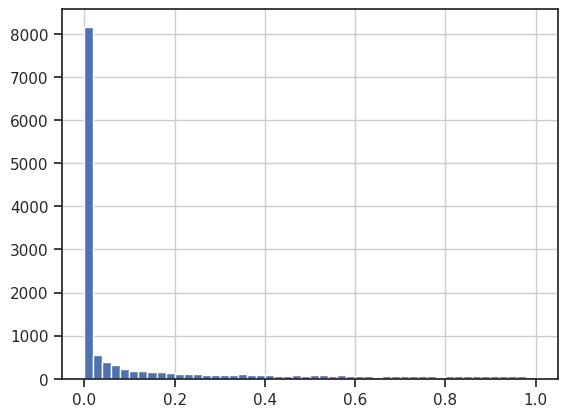

In [364]:
statsummary['pvalue'].hist(bins=50)

In [365]:
statsummary["Significant"]=statsummary.padj<=0.05
statsummary["Log_baseMean"]=np.log10(statsummary["baseMean"] + 1)


Text(0.5, 1.0, 'MA plot')

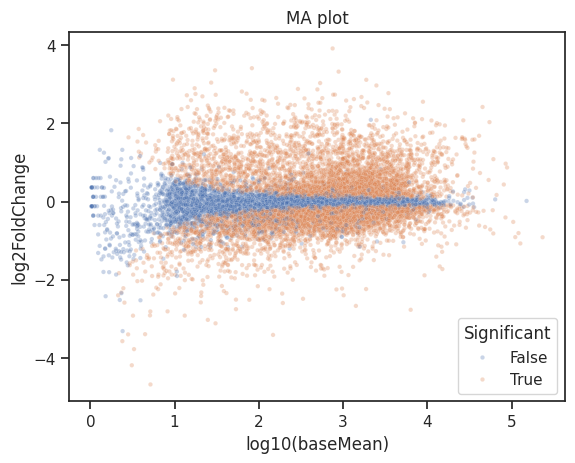

In [366]:
sns.scatterplot(x="Log_baseMean",y="log2FoldChange",hue="Significant",data=statsummary,
                alpha=0.3,s=10)
plt.xlabel("log10(baseMean)")
plt.title("MA plot")

La distribuzione sembra corretta:
I geni significativi (arancioni) dominano su tutto il range di espressione — non sono concentrati solo nei geni altamente espressi, il segnale è distribuito uniformemente
I geni non significativi (blu) si concentrano a sinistra , geni a bassa espressione dove il potere statistico è minore, esattamente quello che ci si aspetta
La distribuzione è simmetrica attorno a 0, ci sono geni up e down regolati in proporzione simile, nessun bias tecnico

In [367]:
statsummary["neglog10"]=-np.log10(statsummary["padj"])

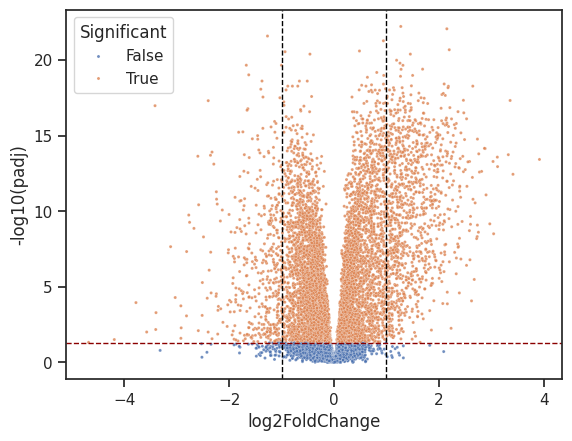

In [368]:
sns.scatterplot( x="log2FoldChange",y="neglog10",data=statsummary,hue="Significant",s=5,
                alpha=0.8)
plt.ylabel("-log10(padj)")

plt.axhline(-np.log10(0.05),color="darkred", linewidth=1,
    linestyle="--")
plt.axvline(1,color="black" ,linewidth=1,
    linestyle="--")
plt.axvline(-1,color="black", linewidth=1,
    linestyle="--")
plt.show()

In [369]:

statsummary[statsummary.padj<0.05].sort_values("log2FoldChange",ascending=False).head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant,Log_baseMean,neglog10
Symbol,,,,,,,,,
Lcn2,748.934231,3.916315,0.491241,7.972295,1.557540e-15,3.816115e-14,True,2.875023,13.418379
Gzmd,81.615005,3.411512,0.446183,7.645988,2.073468e-14,3.660660e-13,True,1.917059,12.436441
Tmsb15a,29.218595,3.356923,0.363450,9.236260,2.552635e-20,4.835984e-18,True,1.480274,17.315515
Pdcd1lg2,882.326065,3.323053,0.411372,8.077971,6.585336e-16,1.845403e-14,True,2.946121,13.733909
Fam71b,8.565890,3.117645,0.398888,7.815838,5.459871e-15,1.135096e-13,True,0.980725,12.944967
Dnase1l3,1879.290771,3.113861,0.388135,8.022622,1.035118e-15,2.687909e-14,True,3.274225,13.570585
Dsc2,26.166866,3.042398,0.488092,6.233250,4.568558e-10,3.124132e-09,True,1.434040,8.505271
Inpp5j,532.265173,3.031677,0.382449,7.927011,2.244840e-15,5.215085e-14,True,2.726943,13.282739
Acod1,2478.671733,2.969373,0.457748,6.486917,8.761046e-11,6.891945e-10,True,3.394394,9.161658


L'analisi dei geni differenzialmente espressi in AB1 responders vs non-responders rivela la presenza di un microambiente infiammatorio pre-esistente nei tumori che rispondono alla terapia. Tra i geni più upregolati nei responders troviamo marcatori di linfociti T citotossici (Gzmd, Trbv31), ligandi dei checkpoint immunitari (Pdcd1lg2/PD-L2), mediatori dell'immunità innata (Lcn2, Acod1) e marcatori di morte cellulare immunogenica (Dnase1l3). Nel complesso, questi risultati suggeriscono che i tumori AB1 che rispondono al blocco di CTLA4/PD-L1 sono caratterizzati da un microambiente già immunologicamente attivo prima del trattamento, consistente con quanto riportato in letteratura sui predittori di risposta ai checkpoint inhibitor.

In [371]:
statsummary_AB1=statsummary.copy()

## Renca
Ripetiamo gli stessi step con l'altra linea cellulare.

In [377]:
metadata_RZ=metadata[metadata.Tumor_Type!="AB1"] # Escludiamo questa volta AB1
pydeseq_counts_RZ=pydeseq_counts.loc[metadata_RZ.index]

dds_RZ = DeseqDataSet(
    counts=pydeseq_counts_RZ,
    metadata=metadata_RZ,
    design="~Treatment_Response")

dds_RZ.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 30.72 seconds.

Fitting dispersion trend curve...
... done in 1.97 seconds.

Fitting MAP dispersions...
... done in 45.61 seconds.

Fitting LFCs...
... done in 10.44 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 18 outlier genes.

Fitting dispersions...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.06 seconds.



In [378]:
stat_res = DeseqStats(dds_RZ, contrast=["Treatment_Response", "Responder", "Non-responder"])
stat_res.summary()

Running Wald tests...
... done in 4.79 seconds.



Log2 fold change & Wald test p-value: Treatment_Response Responder vs Non-responder
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Symbol                                                                      
Gnai3           3748.572886        0.011576  0.019527  0.592818  0.553303   
Cdc45            821.960117       -0.142410  0.054308 -2.622254  0.008735   
H19             2901.228285        0.475536  0.342788  1.387259  0.165363   
Scml2             23.892960        0.023720  0.148080  0.160183  0.872737   
Narf             615.323341        0.014666  0.070887  0.206893  0.836093   
...                     ...             ...       ...       ...       ...   
KIAA1683          35.481747       -0.686296  0.160617 -4.272888  0.000019   
Olfr369-ps1        5.393606        0.529597  0.322683  1.641227  0.100750   
CAAA01180111.2    23.144260        0.106759  0.158232  0.674700  0.499867   
CH25-395E5.2      17.812855        0.159972  0.176301  0.907381  0.36

In [380]:
statsummary_RZ= stat_res.results_df
print(f"Geni significativi {len(statsummary_RZ[statsummary_RZ.padj<0.05])}")
statsummary_RZ[statsummary_RZ.padj<0.05].sort_values("log2FoldChange",ascending=False)

Geni significativi 2852


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Symbol,,,,,,
Trbv17,12.915412,1.803439,0.461398,3.908642,9.281649e-05,0.001663
Slc17a6,24.940420,1.734607,0.392175,4.423046,9.731881e-06,0.000393
Trav7d-4,13.112092,1.691485,0.405508,4.171272,3.029037e-05,0.000812
Trav7-4,12.978422,1.606270,0.419320,3.830651,1.278049e-04,0.002066
9130208D14Rik,385.831719,1.538637,0.418315,3.678174,2.349095e-04,0.003141
...,...,...,...,...,...,...
Plet1,82.602763,-0.916709,0.278438,-3.292334,9.935970e-04,0.008819
Ccl17,218.836496,-0.936405,0.309467,-3.025863,2.479248e-03,0.017311
Kcne3,170.544460,-0.954908,0.193667,-4.930680,8.194408e-07,0.000099


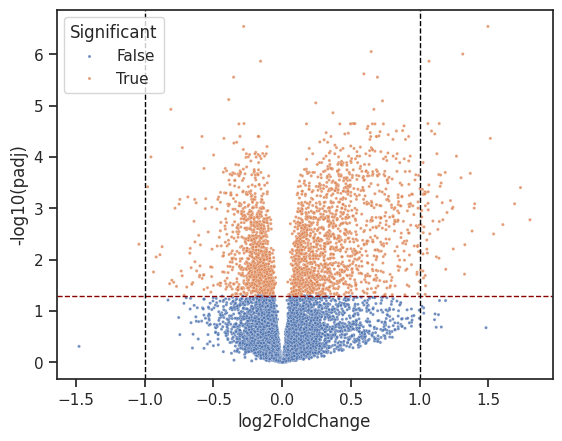

In [383]:
statsummary_RZ["Significant"]=statsummary_RZ.padj<=0.05
statsummary_RZ["Log_baseMean"]=np.log10(statsummary_RZ["baseMean"] + 1)
statsummary_RZ["neglog10"]=-np.log10(statsummary_RZ["padj"])
sns.scatterplot( x="log2FoldChange",y="neglog10",data=statsummary_RZ,hue="Significant",s=5,
                alpha=0.8)
plt.ylabel("-log10(padj)")

plt.axhline(-np.log10(0.05),color="darkred", linewidth=1,
    linestyle="--")
plt.axvline(1,color="black" ,linewidth=1,
    linestyle="--")
plt.axvline(-1,color="black", linewidth=1,
    linestyle="--")
plt.show()

In [381]:
statsummary_RZ[statsummary_RZ.padj<0.05].sort_values("log2FoldChange",ascending=False).head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Symbol,,,,,,
Trbv17,12.915412,1.803439,0.461398,3.908642,9.281649e-05,1.663150e-03
Slc17a6,24.940420,1.734607,0.392175,4.423046,9.731881e-06,3.925490e-04
Trav7d-4,13.112092,1.691485,0.405508,4.171272,3.029037e-05,8.120528e-04
Trav7-4,12.978422,1.606270,0.419320,3.830651,1.278049e-04,2.066076e-03
9130208D14Rik,385.831719,1.538637,0.418315,3.678174,2.349095e-04,3.141147e-03
Trbv31,27.084575,1.515316,0.290002,5.225186,1.739804e-07,4.329815e-05
Pdcd1,330.565663,1.497380,0.224579,6.667496,2.602037e-11,2.859011e-07
Wdr95,9.531757,1.400934,0.335900,4.170685,3.036854e-05,8.124971e-04
Trbv29,13.654709,1.397859,0.340802,4.101676,4.101690e-05,9.872498e-04
